# 실습 2 · 예제 5: 반려동물 이미지 데이터셋 구축하기

고양이와 강아지 이미지가 섞여 있는 RAW 폴더를 **학습에 사용할 수 있는 데이터셋**으로 정리합니다.

**실습 순서:** 원본 확인 → 파일명에서 라벨 추출 → 클래스별 폴더 분류 → 파일명 통일 → Train / Validation / Test 분할 → 데이터셋 확인 → MLP 학습 및 평가

- 제공 데이터: 고양이 150장, 강아지 150장, 총 300장
- 원본 파일명: `cat_영문숫자ID.jpg`, `dog_영문숫자ID.jpg`
- 클래스 이름: `cat`, `dog`
- `____` 부분을 작성한 뒤, 위에서부터 순서대로 실행하세요.
- 데이터셋 구축 후 간단한 MLP 학습과 평가까지 진행합니다. GPU 없이 CPU로도 실행할 수 있습니다.

> 파일명에 정답이 이미 들어 있습니다. 이번 작업은 새로운 정답을 추측하는 것이 아니라, **파일명에 있는 라벨을 폴더 구조로 옮기는 과정**입니다.

## 1. Google Colab에 RAW 데이터 업로드하기

실습 GitHub의 README에 있는 Google Drive 링크에서 RAW 데이터셋을 다운로드한 뒤, Colab에 직접 업로드합니다.
Google Drive를 Colab에 연결할 필요는 없습니다.

1. Colab에서 이 노트북을 엽니다.
2. [실습 GitHub](https://github.com/currycurry915/deeplearning_basics)의 README에서 **예제5 → RAW 데이터셋 다운로드 (Google Drive)** 링크를 클릭합니다.
3. Google Drive에서 `pet_raw.zip` 파일을 컴퓨터에 다운로드합니다. 압축은 해제하지 마세요.
4. 아래 셀을 실행하고 **파일 선택** 버튼에서 다운로드한 `pet_raw.zip`을 선택합니다.
5. 압축 해제가 끝나면 `/content/pet_dataset_300/raw`에 고양이·강아지 이미지 총 300장이 생성됩니다.
6. TODO 1의 `DATA_ROOT`에는 `/content/pet_dataset_300`을 작성합니다.

업로드 및 압축 해제 코드는 제공 코드입니다. 수정하지 않고 실행하세요.
같은 ZIP으로 이 셀을 다시 실행해도 기존 파일의 내용이 같으면 그대로 유지합니다.

> Colab의 파일은 임시 런타임에 저장됩니다. 런타임이 초기화되거나 종료되면 사라질 수 있으므로, 필요하면 ZIP을 다시 업로드하고 결과 파일은 종료 전에 내려받으세요.
>
> 이 실습은 추가 패키지 설치 없이 진행하며, GPU 없이 CPU로도 실행할 수 있습니다.

In [3]:
from pathlib import Path
from io import BytesIO
import re
import zipfile
from google.colab import files as colab_files

uploaded = colab_files.upload()
assert len(uploaded) == 1, "제공된 pet_raw.zip 파일 하나만 선택하세요."
zip_name, zip_data = next(iter(uploaded.items()))
assert zip_name.lower().endswith(".zip"), "ZIP 파일을 선택하세요."

UPLOAD_ROOT = Path("/content/pet_dataset_300")
metadata_files = {
    "README.txt",
    "_관리용/source_mapping.csv",
    "_관리용/source_README",
}
pending_files = []
archive_names = set()
counts = {"cat": 0, "dog": 0}

# 제공된 ZIP의 구조와 파일 내용을 먼저 확인합니다.
with zipfile.ZipFile(BytesIO(zip_data)) as archive:
    assert sum(info.file_size for info in archive.infolist()) <= 100 * 1024 * 1024, "제공된 실습 ZIP을 선택하세요."
    for info in archive.infolist():
        if info.is_dir():
            continue
        name = info.filename
        image_match = re.fullmatch(r"raw/(cat|dog)_[a-z0-9]{12}\.jpg", name)
        assert image_match or name in metadata_files, f"허용되지 않은 ZIP 경로입니다: {name}"
        assert name not in archive_names, f"ZIP 안에 같은 경로가 중복됩니다: {name}"
        archive_names.add(name)
        if image_match:
            counts[image_match.group(1)] += 1
        destination = UPLOAD_ROOT / name
        assert destination.resolve().is_relative_to(UPLOAD_ROOT.resolve())
        data = archive.read(info)
        if destination.exists():
            assert destination.is_file() and destination.read_bytes() == data, f"다른 파일이 이미 있습니다: {destination}"
        pending_files.append((destination, data))

assert counts == {"cat": 150, "dog": 150}, "고양이 150장과 강아지 150장이 들어 있는 300장 버전의 pet_raw.zip을 선택하세요."

# 같은 파일은 건너뛰고, 없는 파일만 저장합니다.
for destination, data in pending_files:
    if not destination.exists():
        destination.parent.mkdir(parents=True, exist_ok=True)
        with destination.open("xb") as file:
            file.write(data)

del uploaded, zip_data, pending_files
print("RAW 데이터 준비 완료:", UPLOAD_ROOT / "raw")
print("고양이:", counts["cat"], "장 / 강아지:", counts["dog"], "장")

Saving pet_raw.zip to pet_raw.zip
RAW 데이터 준비 완료: /content/pet_dataset_300/raw
고양이: 150 장 / 강아지: 150 장


In [4]:
from pathlib import Path
from collections import Counter
from datetime import datetime
import csv
import hashlib
import math
import random
import re
import shutil

from PIL import Image
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms

SEED = 777
CLASS_NAMES = ["cat", "dog"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

## ✏️ TODO 1: 데이터 폴더 경로 설정하기

`DATA_ROOT`에 `/content/pet_dataset_300`을 입력하세요.

- 이미지가 들어 있는 `raw` 폴더의 상위 경로입니다. 끝에 `/raw`를 붙이지 마세요.
- 원본은 유지되며, 실행 결과는 `work` 폴더 아래에 저장됩니다.

> 이 셀을 다시 실행하면 새 결과 폴더가 만들어집니다.

In [6]:
DATA_ROOT = Path("___").expanduser().resolve()

RAW_DIR = DATA_ROOT / "raw"
assert RAW_DIR.is_dir(), f"raw 폴더를 찾을 수 없습니다: {RAW_DIR}"

RUN_ROOT = DATA_ROOT / "work" / datetime.now().strftime("run_%Y%m%d_%H%M%S_%f")
CLASSIFIED_DIR = RUN_ROOT / "classified"
RENAMED_DIR = RUN_ROOT / "renamed"
SPLIT_DIR = RUN_ROOT / "dataset"
RUN_ROOT.mkdir(parents=True, exist_ok=False)

print("원본 폴더:", RAW_DIR)
print("이번 실행 결과:", RUN_ROOT)

원본 폴더: /content/pet_dataset_300/raw
이번 실행 결과: /content/pet_dataset_300/work/run_20261005_155031_198236


### 원본 보호를 위한 제공 함수

아래 함수는 수정하지 않고 실행하세요.

- 이미지 파일만 골라 이름순으로 정렬합니다.
- 복사 위치를 이번 작업 폴더 안으로 제한합니다.
- 같은 파일을 다시 복사하면 건너뛰고, 내용이 다른 파일은 덮어쓰지 않습니다.
- 파일 내용의 해시를 이용해 원본 변경과 동일 파일 중복을 확인합니다.

In [8]:
def image_files(folder):
    return sorted(
        path for path in Path(folder).iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

def file_hash(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def safe_copy(source, destination):
    source = Path(source)
    destination = Path(destination)
    if not destination.resolve().is_relative_to(RUN_ROOT.resolve()):
        raise ValueError("복사 위치는 이번 실행의 RUN_ROOT 안이어야 합니다.")
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists():
        if destination.is_file() and file_hash(source) == file_hash(destination):
            return
        raise FileExistsError(f"다른 내용의 파일이 이미 있습니다: {destination}")
    shutil.copy2(source, destination)

def show_counts(root):
    for label in CLASS_NAMES:
        folder = Path(root) / label
        count = len(image_files(folder)) if folder.is_dir() else 0
        print(f"{label}: {count}장")

## 2. RAW 데이터 확인하기

`raw` 안에는 클래스별 하위 폴더 없이 이미지가 함께 들어 있습니다.

- 파일명의 첫 번째 `_` 앞부분은 클래스 이름입니다.
- 뒤의 영문·숫자 조합은 이미지를 구분하는 ID입니다.
- 탐색기에서 이름순으로 정렬하면 cat과 dog가 모여 보이지만, 두 클래스 모두 같은 폴더에 있습니다.

In [9]:
raw_files = image_files(RAW_DIR)
assert raw_files, "raw 폴더에 이미지가 없습니다."

raw_snapshot = {path.name: file_hash(path) for path in raw_files}
assert len(set(raw_snapshot.values())) == len(raw_files), "동일한 내용의 이미지가 중복되어 있습니다."

print("전체 이미지 수:", len(raw_files))
for label in CLASS_NAMES:
    count = sum(path.name.startswith(label + "_") for path in raw_files)
    print(f"{label}: {count}장")

print("\n파일명 예시")
for path in random.Random(SEED).sample(raw_files, min(6, len(raw_files))):
    print(path.name)

전체 이미지 수: 300
cat: 150장
dog: 150장

파일명 예시
cat_rygregt3fm2q.jpg
dog_lcuxioj3c47r.jpg
dog_b3puuge76rpc.jpg
dog_ytkt8xl4usb4.jpg
cat_xjhyird7xr6z.jpg
dog_6zdyic8oxmrt.jpg


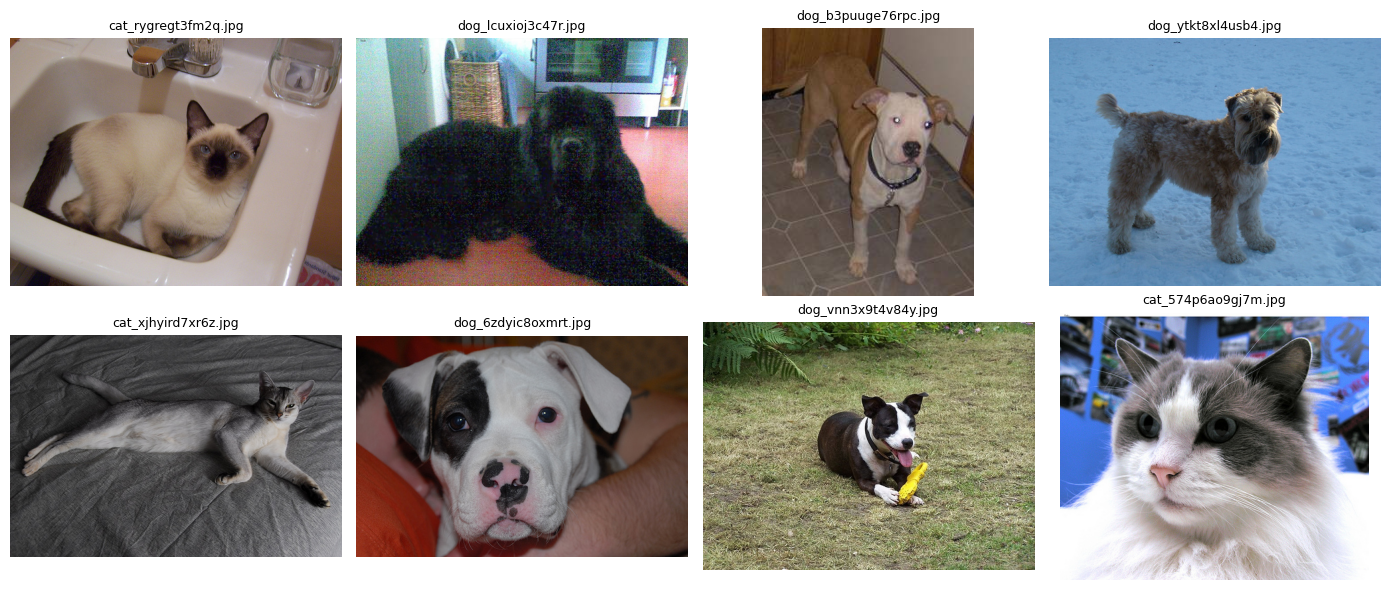

In [10]:
sample_files = random.Random(SEED).sample(raw_files, min(8, len(raw_files)))

plt.figure(figsize=(14, 6))
for index, path in enumerate(sample_files, start=1):
    plt.subplot(2, 4, index)
    with Image.open(path) as image:
        plt.imshow(image.convert("RGB"))
    plt.title(path.name, fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## ✏️ TODO 2: 클래스별 폴더로 이미지 분류하기

아래 코드의 빈칸 `"___"`에 파일명에 맞는 클래스 이름을 입력하세요.

- `cat_`으로 시작하는 경우: `"cat"` 입력
- `dog_`으로 시작하는 경우: `"dog"` 입력

이미지는 각각 `classified/cat`, `classified/dog` 폴더로 복사됩니다.
원본은 유지되며, 폴더 이름이 클래스 이름이 됩니다.

In [11]:
for label in CLASS_NAMES:
    (CLASSIFIED_DIR / label).mkdir(parents=True, exist_ok=True)

for path in raw_files:
    if path.name.startswith("cat_"):
        label = "___"  # 고양이 폴더 이름 "cat" 입력
    elif path.name.startswith("dog_"):
        label = "___"  # 강아지 폴더 이름 "dog" 입력
    else:
        raise ValueError(f"알 수 없는 파일명입니다: {path.name}")

    destination = CLASSIFIED_DIR / label / path.name
    safe_copy(path, destination)

print("클래스별 폴더 분류 완료")
show_counts(CLASSIFIED_DIR)

클래스별 폴더 분류 완료
cat: 150장
dog: 150장


## 3. 파일명을 순차 번호로 통일하기

아래 코드는 수정하지 않고 실행하세요.
복잡한 파일명을 클래스 이름과 순차 번호로 정리합니다.

- 고양이: `cat_001.jpg`, `cat_002.jpg`, …
- 강아지: `dog_001.jpg`, `dog_002.jpg`, …

이미지는 새 이름으로 `renamed` 폴더에 복사되며, 원본 파일은 유지됩니다.
기존 파일명과 새 파일명의 대응표는 `filename_mapping.csv`에 저장됩니다.

In [12]:
rename_records = []

for label in CLASS_NAMES:
    files = image_files(CLASSIFIED_DIR / label)
    for index, path in enumerate(files, start=1):
        new_name = f"{label}_{index:03d}{path.suffix.lower()}"  # TODO: 클래스명_세자리번호.확장자 형식으로 작성
        expected_pattern = rf"{label}_[0-9]{{3,}}{re.escape(path.suffix.lower())}"
        assert isinstance(new_name, str) and re.fullmatch(expected_pattern, new_name), "파일명 형식을 확인하세요."
        destination = RENAMED_DIR / label / new_name
        safe_copy(path, destination)

        rename_records.append({
            "label": label,
            "raw_filename": path.name,
            "new_filename": new_name,
            "sha256": file_hash(path),
        })

mapping_path = RUN_ROOT / "filename_mapping.csv"
with mapping_path.open("w", newline="", encoding="utf-8-sig") as file:
    writer = csv.DictWriter(file, fieldnames=["label", "raw_filename", "new_filename", "sha256"])
    writer.writeheader()
    writer.writerows(rename_records)

assert len({row["new_filename"] for row in rename_records}) == len(raw_files)
print("파일명 정리 완료")
show_counts(RENAMED_DIR)
print("대응표:", mapping_path)
for label in CLASS_NAMES:
    print(label, "예시:", [path.name for path in image_files(RENAMED_DIR / label)[:3]])

파일명 정리 완료
cat: 150장
dog: 150장
대응표: /content/pet_dataset_300/work/run_20261005_155031_198236/filename_mapping.csv
cat 예시: ['cat_001.jpg', 'cat_002.jpg', 'cat_003.jpg']
dog 예시: ['dog_001.jpg', 'dog_002.jpg', 'dog_003.jpg']


## 3. 학습용·검증용·테스트용 데이터 나누기

이미지를 용도에 따라 세 부분으로 나눕니다.

- **Train(학습용)**: 모델이 고양이와 강아지를 구분하는 방법을 배우는 데 사용합니다.
- **Validation(검증용)**: 학습 중 모델이 잘 배우고 있는지 확인합니다.
- **Test(테스트용)**: 학습이 끝난 뒤, 새로운 이미지를 얼마나 잘 구분하는지 확인합니다.

## ✏️ TODO 4: 데이터 분할 비율 설정하기

아래 빈칸에 학습용·검증용·테스트용 데이터의 비율을 입력하세요.

- `train_ratio`: `0.8` 입력 → 학습용 80%
- `validation_ratio`: `0.1` 입력 → 검증용 10%
- `test_ratio`: `0.1` 입력 → 테스트용 10%

전체 300장이 학습용 240장, 검증용 30장, 테스트용 30장으로 나뉩니다.

In [14]:
train_ratio = ___       # TODO: Train 비율
validation_ratio = ___  # TODO: Validation 비율
test_ratio = ___        # TODO: Test 비율

ratios = [train_ratio, validation_ratio, test_ratio]
assert all(isinstance(value, (int, float)) and 0 < value < 1 for value in ratios), "각 비율은 0보다 크고 1보다 작아야 합니다."
assert math.isclose(sum(ratios), 1.0, abs_tol=1e-9), "세 비율의 합은 1이어야 합니다."

print(f"Train: {train_ratio:.0%}, Validation: {validation_ratio:.0%}, Test: {test_ratio:.0%}")

Train: 80%, Validation: 10%, Test: 10%


### 이미지 분할하기 — 제공 코드

아래 코드는 클래스별 이미지 순서를 섞고, 설정한 비율에 맞추어 복사합니다.
분할된 파일 목록은 `split_manifest.csv`에 저장합니다.

최종 폴더 구조:

```text
dataset/
├── train/
│   ├── cat/
│   └── dog/
├── validation/
│   ├── cat/
│   └── dog/
└── test/
    ├── cat/
    └── dog/
```

In [15]:
split_records = []
rng = random.Random(SEED)

for label in CLASS_NAMES:
    files = image_files(RENAMED_DIR / label)
    rng.shuffle(files)

    train_count = int(len(files) * train_ratio)
    validation_count = int(len(files) * validation_ratio)
    test_count = len(files) - train_count - validation_count
    assert min(train_count, validation_count, test_count) > 0, "각 클래스가 세 분할에 모두 포함되도록 비율을 조정하세요."

    groups = {
        "train": files[:train_count],
        "validation": files[train_count:train_count + validation_count],
        "test": files[train_count + validation_count:],
    }

    for split_name, split_files in groups.items():
        for path in split_files:
            destination = SPLIT_DIR / split_name / label / path.name
            safe_copy(path, destination)
            split_records.append({
                "split": split_name,
                "label": label,
                "filename": path.name,
                "relative_path": destination.relative_to(SPLIT_DIR).as_posix(),
            })

manifest_path = RUN_ROOT / "split_manifest.csv"
with manifest_path.open("w", newline="", encoding="utf-8-sig") as file:
    writer = csv.DictWriter(file, fieldnames=["split", "label", "filename", "relative_path"])
    writer.writeheader()
    writer.writerows(split_records)

for split_name in ["train", "validation", "test"]:
    print(f"\n[{split_name}]")
    show_counts(SPLIT_DIR / split_name)


[train]
cat: 120장
dog: 120장

[validation]
cat: 15장
dog: 15장

[test]
cat: 15장
dog: 15장


## 4. 나누어진 이미지 수 확인하기

아래 코드를 실행하여 학습용·검증용·테스트용 이미지 수를 확인하세요.

80% / 10% / 10%로 설정했다면 각각 240장, 30장, 30장이 나옵니다.

In [16]:
for split_name in ["train", "validation", "test"]:
    count = 0

    for label in CLASS_NAMES:
        count += len(image_files(SPLIT_DIR / split_name / label))

    print(f"{split_name}: {count}장")

train: 240장
validation: 30장
test: 30장


## 5. 학습에 사용할 이미지 불러오기

`ImageFolder`를 사용하여 앞에서 정리한 이미지를 불러옵니다.

- `cat`, `dog` 폴더 이름을 보고 고양이와 강아지를 구분합니다.
- 학습용·검증용·테스트용 이미지를 각각 불러옵니다.
- 이미지 크기를 64×64로 맞추고, 모델에 입력할 수 있는 숫자 형태(Tensor)로 바꿉니다.

## ✏️ TODO 5: 데이터셋 불러오기

아래 빈칸에 폴더 이름을 입력하세요.

- `train_dataset`: `train`
- `validation_dataset`: `validation`
- `test_dataset`: `test`

In [17]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root=SPLIT_DIR / "___", transform=transform)        # 학습용 폴더 이름 "train" 입력
validation_dataset = datasets.ImageFolder(root=SPLIT_DIR / "___", transform=transform)   # 검증용 폴더 이름 "validation" 입력
test_dataset = datasets.ImageFolder(root=SPLIT_DIR / "___", transform=transform)         # 테스트용 폴더 이름 "test" 입력

assert train_dataset.class_to_idx == validation_dataset.class_to_idx == test_dataset.class_to_idx
assert train_dataset.classes == CLASS_NAMES

print("클래스 이름 → 숫자 라벨:", train_dataset.class_to_idx)
print("Train:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Test:", len(test_dataset))

클래스 이름 → 숫자 라벨: {'cat': 0, 'dog': 1}
Train: 240
Validation: 30
Test: 30


### 배치 구성 및 이미지 확인

Train은 데이터를 섞고, Validation과 Test는 순서를 유지합니다.

한 배치의 이미지 크기와 숫자 라벨을 확인하세요.
이미지 Tensor의 차원 순서는 **(배치 크기, 채널 수, 높이, 너비)**입니다.

In [18]:
batch_size = 16

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=0, generator=torch.Generator().manual_seed(SEED)
)
validation_loader = torch.utils.data.DataLoader(
    validation_dataset, batch_size=batch_size, shuffle=False, num_workers=0
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=0
)

images, labels = next(iter(train_loader))
print("이미지 배치 크기:", tuple(images.shape))
print("라벨 배치 크기:", tuple(labels.shape))
print("숫자 라벨:", labels.tolist())

이미지 배치 크기: (16, 3, 64, 64)
라벨 배치 크기: (16,)
숫자 라벨: [0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1]


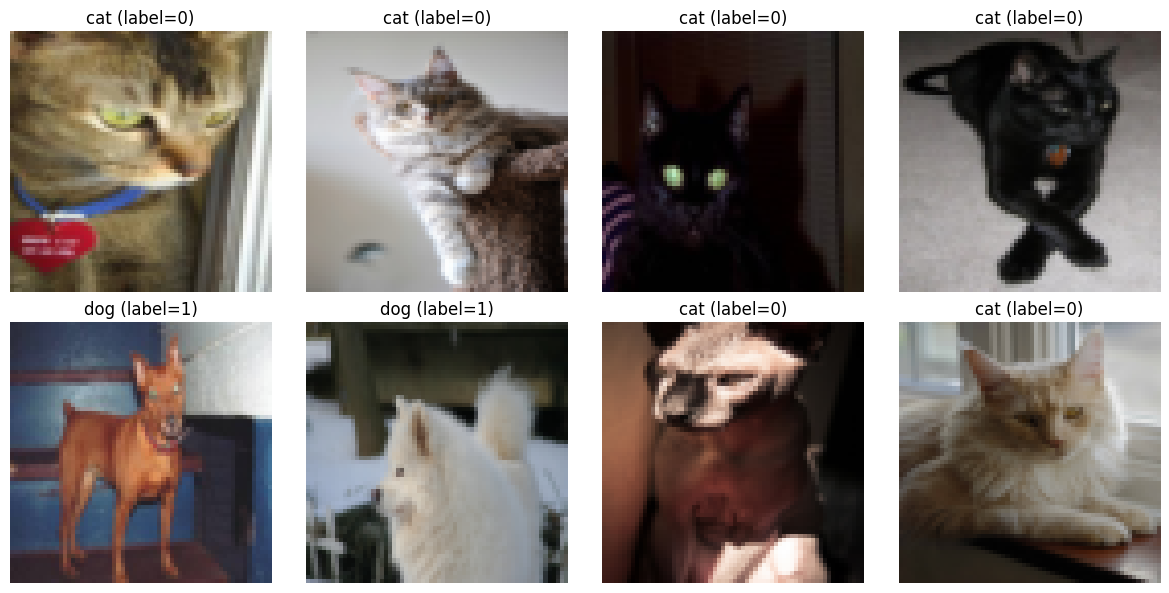

In [19]:
plt.figure(figsize=(12, 6))
for index in range(min(8, len(images))):
    plt.subplot(2, 4, index + 1)
    plt.imshow(images[index].permute(1, 2, 0).numpy())
    label_index = labels[index].item()
    plt.title(f"{train_dataset.classes[label_index]} (label={label_index})")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 6. 직접 구축한 데이터셋으로 MLP 학습하기

앞에서 정리한 고양이·강아지 이미지로 MLP(다층 퍼셉트론)를 학습합니다.
아래 코드는 빈칸 없이 그대로 실행하세요.

- **입력**: 64×64 크기의 컬러 이미지를 사용합니다. RGB 3개 채널의 값을 펼쳐, 이미지 한 장을 12,288개의 숫자로 입력합니다.
- **은닉층**: 뉴런이 64개인 층과 32개인 층을 차례로 거치며 이미지의 특징을 학습합니다. 각 층에는 활성화 함수 ReLU를 사용합니다.
- **출력**: 고양이 점수와 강아지 점수, 총 2개를 출력합니다. 점수가 더 높은 쪽을 예측 결과로 선택합니다.
- **손실 함수**: `CrossEntropyLoss`로 예측과 정답의 차이를 계산합니다. 이 함수에 출력 점수를 그대로 전달하므로, 마지막에 Softmax를 따로 추가하지 않습니다.
- **실행 환경**: GPU가 있으면 사용하고, 없으면 CPU로 실행합니다.

전체 300장 중 240장은 학습에, 30장은 학습 상태 확인에, 나머지 30장은 최종 테스트에 사용합니다.

> 데이터가 적어 정확도가 높지 않을 수 있습니다. 직접 만든 데이터셋을 모델 학습과 결과 확인까지 연결해 보는 실습입니다.

In [20]:
import copy
import torch.nn as nn

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
train_loader.generator.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 20
learning_rate = 0.001
num_classes = len(train_dataset.classes)

# (batch, 3, 64, 64) → (batch, 12288) → 64 → 32 → 2
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * 64 * 64, 64),
    nn.ReLU(),
    nn.Dropout(p=0.1),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(p=0.1),
    nn.Linear(32, num_classes)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("연산 장치:", device)
print("클래스:", train_dataset.class_to_idx)
print(model)

연산 장치: cpu
클래스: {'cat': 0, 'dog': 1}
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=12288, out_features=64, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.1, inplace=False)
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.1, inplace=False)
  (7): Linear(in_features=32, out_features=2, bias=True)
)


### 학습 및 검증

Train 데이터로만 가중치를 업데이트합니다.
매 epoch가 끝나면 Validation 데이터로 Loss와 Accuracy를 확인하고,
**Validation Loss가 가장 낮았던 모델**을 최종 평가에 사용합니다.

- `model.train()`: 학습 모드
- `model.eval()`과 `torch.no_grad()`: 평가 모드 및 기울기 계산 중지
- Loss는 배치 크기를 반영한 전체 이미지의 평균입니다.
- 학습을 처음부터 다시 하려면 위의 모델 생성 셀부터 실행하세요.
- 설정 변경은 Validation 결과를 기준으로 하고, Test는 설정 선택이 끝난 뒤 평가하세요.

In [21]:
history = {
    "train_loss": [], "validation_loss": [],
    "train_accuracy": [], "validation_accuracy": []
}
best_validation_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())
best_epoch = 0

for epoch in range(1, epochs + 1):
    # 1. Train 데이터로 학습
    model.train()
    train_loss_sum = 0.0
    train_correct = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * labels.size(0)
        train_correct += (output.argmax(dim=1) == labels).sum().item()

    train_loss = train_loss_sum / len(train_dataset)
    train_accuracy = 100 * train_correct / len(train_dataset)

    # 2. Validation 데이터로 학습 상태 확인
    model.eval()
    validation_loss_sum = 0.0
    validation_correct = 0

    with torch.no_grad():
        for images, labels in validation_loader:
            images = images.to(device)
            labels = labels.to(device)
            output = model(images)
            loss = criterion(output, labels)

            validation_loss_sum += loss.item() * labels.size(0)
            validation_correct += (output.argmax(dim=1) == labels).sum().item()

    validation_loss = validation_loss_sum / len(validation_dataset)
    validation_accuracy = 100 * validation_correct / len(validation_dataset)

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)
    history["train_accuracy"].append(train_accuracy)
    history["validation_accuracy"].append(validation_accuracy)

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_model_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.2f}% | "
        f"Validation Loss: {validation_loss:.4f}, Accuracy: {validation_accuracy:.2f}%"
    )

# 마지막 epoch가 아니라 Validation Loss가 가장 낮았던 가중치로 복원
model.load_state_dict(best_model_state)
print(f"학습 완료: epoch {best_epoch} 모델 선택 (Validation Loss: {best_validation_loss:.4f})")

Epoch 01/20 | Train Loss: 0.7697, Accuracy: 48.75% | Validation Loss: 0.6853, Accuracy: 56.67%
Epoch 02/20 | Train Loss: 0.6946, Accuracy: 53.33% | Validation Loss: 0.7148, Accuracy: 50.00%
Epoch 03/20 | Train Loss: 0.7406, Accuracy: 48.33% | Validation Loss: 0.7316, Accuracy: 50.00%
Epoch 04/20 | Train Loss: 0.7200, Accuracy: 46.67% | Validation Loss: 0.6952, Accuracy: 50.00%
Epoch 05/20 | Train Loss: 0.7022, Accuracy: 47.92% | Validation Loss: 0.6922, Accuracy: 53.33%
Epoch 06/20 | Train Loss: 0.6917, Accuracy: 52.92% | Validation Loss: 0.6941, Accuracy: 50.00%
Epoch 07/20 | Train Loss: 0.6861, Accuracy: 56.25% | Validation Loss: 0.6875, Accuracy: 50.00%
Epoch 08/20 | Train Loss: 0.6736, Accuracy: 57.92% | Validation Loss: 0.6965, Accuracy: 46.67%
Epoch 09/20 | Train Loss: 0.6878, Accuracy: 55.00% | Validation Loss: 0.6879, Accuracy: 53.33%
Epoch 10/20 | Train Loss: 0.6704, Accuracy: 56.67% | Validation Loss: 0.6872, Accuracy: 56.67%
Epoch 11/20 | Train Loss: 0.6631, Accuracy: 62.08%

### 학습 결과 그래프

Train과 Validation의 Loss 및 Accuracy 변화를 비교하세요.
Train 성능만 좋아지고 Validation 성능은 좋아지지 않는다면 과적합 가능성을 살펴보세요.

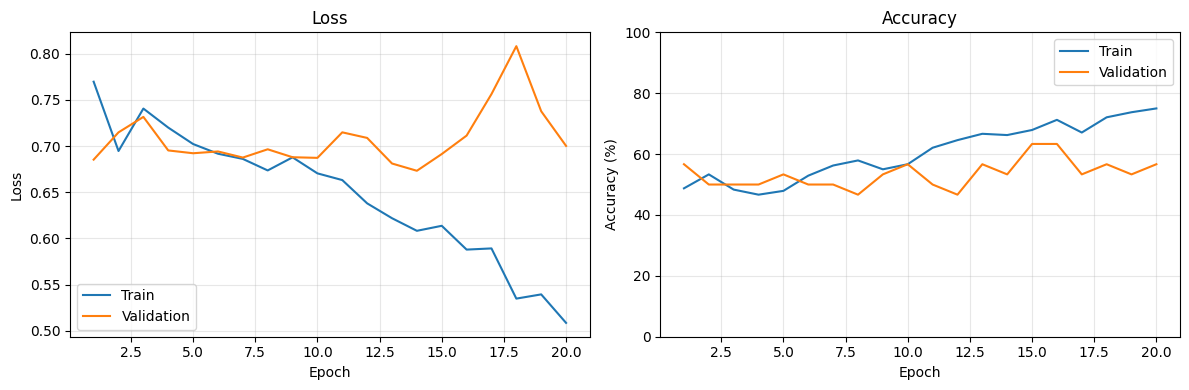

In [22]:
epoch_numbers = range(1, epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epoch_numbers, history["train_loss"], label="Train")
plt.plot(epoch_numbers, history["validation_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epoch_numbers, history["train_accuracy"], label="Train")
plt.plot(epoch_numbers, history["validation_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.title("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Test 데이터로 최종 결과 확인하기

Validation으로 선택한 모델을 Test 데이터 전체에 적용합니다.
Test 데이터는 가중치 업데이트와 모델 선택에 사용하지 않습니다.

- 전체 Test Loss와 Accuracy를 출력합니다.
- 일부 테스트 이미지의 실제 클래스와 예측 클래스를 비교합니다.
- 초록색 제목은 정답, 빨간색 제목은 오답입니다.
- 기본 분할에서는 테스트 이미지가 30장이므로, 한 장의 정오에 따라 정확도가 약 3.33%p 달라집니다.
- Test 결과를 보고 설정을 반복 조정하지 마세요.

In [23]:
model.eval()
test_loss_sum = 0.0
test_correct = 0
test_predictions = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)
        loss = criterion(output, labels)
        predictions = output.argmax(dim=1)

        test_loss_sum += loss.item() * labels.size(0)
        test_correct += (predictions == labels).sum().item()
        test_predictions.extend(predictions.cpu().tolist())
        test_labels.extend(labels.cpu().tolist())

test_loss = test_loss_sum / len(test_dataset)
test_accuracy = 100 * test_correct / len(test_dataset)

print(f"선택된 모델: epoch {best_epoch}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}% ({test_correct}/{len(test_dataset)})")

선택된 모델: epoch 14
Test Loss: 0.6425
Test Accuracy: 66.67% (20/30)


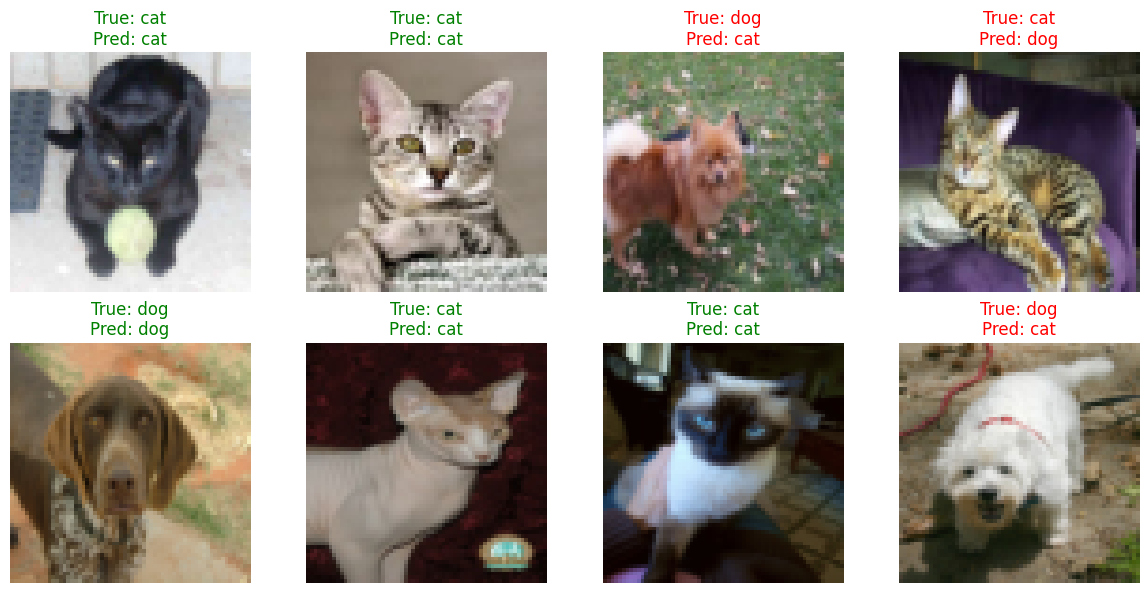

In [24]:
sample_indices = random.Random(SEED).sample(
    range(len(test_dataset)), min(8, len(test_dataset))
)

plt.figure(figsize=(12, 6))
for plot_index, sample_index in enumerate(sample_indices, start=1):
    image, label = test_dataset[sample_index]
    # test_loader는 shuffle=False이므로 예측 결과와 데이터셋의 순서가 같습니다.
    prediction = test_predictions[sample_index]

    plt.subplot(2, 4, plot_index)
    plt.imshow(image.permute(1, 2, 0).numpy())
    plt.title(
        f"True: {test_dataset.classes[label]}\n"
        f"Pred: {test_dataset.classes[prediction]}",
        color="green" if prediction == label else "red"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 선택: 실습 결과 내려받기

Colab 런타임이 종료되기 전에 결과를 보관하려면 아래 두 줄의 주석을 해제하고 실행하세요.

이번 실행의 클래스별 폴더, 파일명 대응표, Train / Validation / Test 데이터셋을 하나의 ZIP으로 내려받습니다.
수강생 TODO가 아닌 선택 제공 코드입니다.

In [25]:
# 필요한 경우에만 아래 두 줄의 주석을 해제하세요.
# result_zip = shutil.make_archive(str(RUN_ROOT), "zip", root_dir=RUN_ROOT)
# colab_files.download(result_zip)

## 데이터 출처

- [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/)
- Omkar M. Parkhi, Andrea Vedaldi, Andrew Zisserman, C. V. Jawahar, **Cats and Dogs**, CVPR 2012.
- 공식 trainval에서 고양이 150장, 강아지 150장을 선정했습니다.